In [1]:
#Importing Libraries--

import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import seaborn as sns 

In [2]:
#1-- Storing the dataset inside a dataframe-

df = pd.read_csv("Employee-Attrition-Dataset.csv")

#2-- Printing the first 5 rows of dataset

print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
print(df.columns) #Printing the column names.. 


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')


In [4]:
df.info() #Gathering info about dataset

<class 'pandas.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1498 non-null   int64
 1   Attrition                 1498 non-null   str  
 2   BusinessTravel            1498 non-null   str  
 3   DailyRate                 1498 non-null   int64
 4   Department                1498 non-null   str  
 5   DistanceFromHome          1498 non-null   int64
 6   Education                 1498 non-null   int64
 7   EducationField            1498 non-null   str  
 8   EmployeeCount             1498 non-null   int64
 9   EmployeeNumber            1498 non-null   int64
 10  EnvironmentSatisfaction   1498 non-null   int64
 11  Gender                    1498 non-null   str  
 12  HourlyRate                1498 non-null   int64
 13  JobInvolvement            1498 non-null   int64
 14  JobLevel                  1498 non-null   int64
 15

In [5]:
#Data-Cleaning

In [6]:
#1-- Checking if there are any missing values present in dataset or not

print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
#-- There are no missing values present in the dataset..

#NOTE: If missing values were present in the dataset, handling them would depend on the data in the dataset itself..

#1--  If there were missing values in only few rows then those rows can be dropped.
#Code-- df.dropna(inplace=True)

#2-- If there were a large number of missing values then mean(balanced dataset), median(dataset containing large no of outliers)
# -- or mode(for categorical features) can be filled in place of them..abs
#Code1-- df['Age'] = df['Age'].fillna(df['Age'].median()) #For mean replace median by mean.. 
#Code2-- df['Department'] = df['Department'].fillna(df['Department'].mode()[0])


In [8]:
#2-- Check if there are any duplicate rows present in the dataset.. 

print(df.duplicated().sum())

# Since the output of above print statement is greater than 0 it means that there are duplicate rows present in our dataset.. 

28


In [9]:
print(df[df.duplicated()]) #This prints a dataframe consisting of only the duplicate rows.. 

      Age Attrition     BusinessTravel  DailyRate              Department  \
1470   33        No      Travel_Rarely        586                   Sales   
1471   33        No      Travel_Rarely        586                   Sales   
1472   33        No      Travel_Rarely        586                   Sales   
1473   33        No      Travel_Rarely        586                   Sales   
1474   33        No      Travel_Rarely        586                   Sales   
1475   31        No         Non-Travel        325  Research & Development   
1476   31        No         Non-Travel        325  Research & Development   
1477   31        No         Non-Travel        325  Research & Development   
1478   31        No         Non-Travel        325  Research & Development   
1479   31        No         Non-Travel        325  Research & Development   
1480   26        No      Travel_Rarely       1167                   Sales   
1481   26        No      Travel_Rarely       1167                   Sales   

In [10]:
#Removing the duplicate rows for data cleaning--

print(len(df)) #No of rows before removing duplicate rows 

df.drop_duplicates(inplace= True) #Removing the duplicate rows

print(len(df)) #No of rows after removing the duplicate rows

print(df.shape) #Shape after dropping duplicate rows.

#The reduction in the number of rows shows us that the duplicate rows were removed!!!

1498
1470
(1470, 35)


In [11]:
print(df.shape) #This is the shape i obtained before dropping the features.. 

#3(A)-- Dropping structurally useless columns--

cols_to_drop_irrelevant = ['Over18', 'StandardHours', 'EmployeeCount']
df.drop(columns=cols_to_drop_irrelevant, inplace = True)

#3(B) -- Dropping analytically unreliable features--

cols_to_drop_unreliable = ['DailyRate', 'MonthlyRate', 'HourlyRate']
df.drop(columns= cols_to_drop_unreliable, inplace= True)


print(df.shape) #Shape which was obtained after dropping features,, 

(1470, 35)
(1470, 29)


In [12]:
#4-- Fixing incorrect data-types..

# There are some columns which are ordinal(categories) but have a int64 datatype as seen in results from df.info()

ordinal_columns = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
                   'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

#Changing the data type to 'category' 

df[ordinal_columns] = df[ordinal_columns].astype('category')

#Data types of columns after fix--

print(df.dtypes)


Age                            int64
Attrition                        str
BusinessTravel                   str
Department                       str
DistanceFromHome               int64
Education                   category
EducationField                   str
EmployeeNumber                 int64
EnvironmentSatisfaction     category
Gender                           str
JobInvolvement              category
JobLevel                    category
JobRole                          str
JobSatisfaction             category
MaritalStatus                    str
MonthlyIncome                  int64
NumCompaniesWorked             int64
OverTime                         str
PercentSalaryHike              int64
PerformanceRating           category
RelationshipSatisfaction    category
StockOptionLevel            category
TotalWorkingYears              int64
TrainingTimesLastYear          int64
WorkLifeBalance             category
YearsAtCompany                 int64
YearsInCurrentRole             int64
Y

In [13]:
#Data-Organization

In [14]:
#NOTE: Method chaining cant be done when we use inplace=True, Nonetype object has no attribute 'reset_index' error understood

In [15]:
df.sort_values(by='MonthlyIncome', ascending=False, inplace=True)

print(df.iloc[:, 15:19].head(), end = "\n\n") #Data is sorted in descending order as per the monthly income

#Now fixing the index numbers by reset_index.. 

df.reset_index(drop = True, inplace = True)

print(df.iloc[:, 15:19].head())

     MonthlyIncome  NumCompaniesWorked OverTime  PercentSalaryHike
190          19999                   0       No                 14
746          19973                   1       No                 22
851          19943                   4       No                 13
165          19926                   3       No                 15
568          19859                   5      Yes                 13

   MonthlyIncome  NumCompaniesWorked OverTime  PercentSalaryHike
0          19999                   0       No                 14
1          19973                   1       No                 22
2          19943                   4       No                 13
3          19926                   3       No                 15
4          19859                   5      Yes                 13


In [16]:
#Data-Analysis

#1-- Statistical Analysis

In [17]:
#1-- Statistics for numerical features(mean[average], percentiles , standard deviation, minimum and maximum)

display(df.describe())

#2-- Statistics for categorical features(Job role, employee satisfaction etc..)

display(df.describe(include=['category', 'object']))

,Age,DistanceFromHome,EmployeeNumber,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,1024.865306,6502.931293,2.693197,15.209524,11.279592,2.799320,7.008163,4.229252,2.187755,4.123129
std,9.135373,8.106864,602.024335,4707.956783,2.498009,3.659938,7.780782,1.289271,6.126525,3.623137,3.222430,3.568136
min,18.000000,1.000000,1.000000,1009.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,491.250000,2911.000000,1.000000,12.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,7.000000,1020.500000,4919.000000,2.000000,14.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,14.000000,1555.750000,8379.000000,4.000000,18.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,29.000000,2068.000000,19999.000000,9.000000,25.000000,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000


C:\Users\aryan\AppData\Local\Temp\ipykernel_14620\2710474422.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['category', 'object']))


,Attrition,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,OverTime,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance
count,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,5,6,4,2,4,5,9,4,3,2,2,4,4,4
top,No,Travel_Rarely,Research & Development,3,Life Sciences,3,Male,3,1,Sales Executive,4,Married,No,3,3,0,3
freq,1233,1043,961,572,606,453,882,868,543,326,459,673,1054,1244,459,631,893


In [18]:
#Some Conclusions from statistical analysis of numerical and categorical features

#1-- mean age = 37 years(approx)
#2-- half of the employees have a work experience less than 10yrs and the other half has more than 10yrs
#3-- Average monthly income = 6503.9 and maximum income obtained by a employee is 19999
#4-- 1233 out of 1470 employees didnt leave the company showing imbalance in the dataset
#5-- Majority of employees work in R&D and are males
#6-- 326 employees work as Sales Executive

In [19]:
#Calculating the attrition rate(percentage of employees that stayed and those who left)

attrition_count = df['Attrition'].value_counts()
attrition_rate = df['Attrition'].value_counts(normalize= True) * 100

print(attrition_count, end = '\n\n')
print(attrition_rate)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [20]:
#Data-Analysis

#2-- EDA, Data Visualization and Relationship Analysis

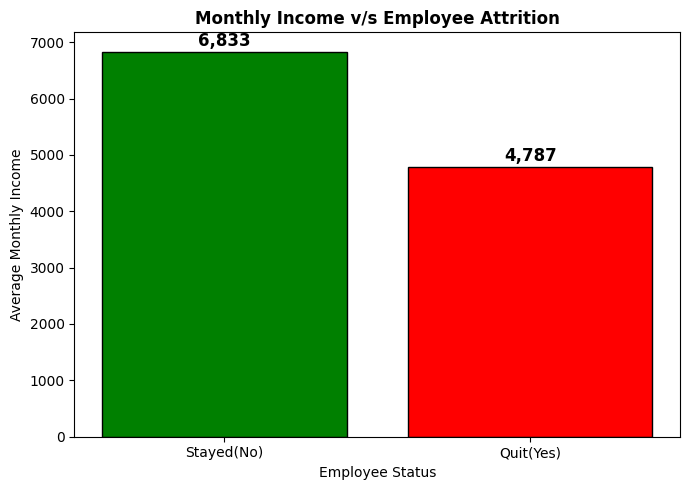

In [21]:
#q1 -- Does monthly income affect employee attrition?


#-- Calculating the average_income of No and Yes(employee attrition) categories using group-by method
average_income = df.groupby('Attrition')['MonthlyIncome'].mean()

#-- Creating the canvas for plotting the graph
plt.figure(figsize=(7,5)) 

labels = ['Stayed(No)', 'Quit(Yes)']
avg_income_values = [average_income['No'], average_income['Yes']]

#-- Plotting the bars to draw the graphs

properties = dict(color = ['Green', 'Red'], edgecolor = 'Black')

bars = plt.bar(labels, avg_income_values, **properties)

plt.title('Monthly Income v/s Employee Attrition', fontweight = 'bold')
plt.xlabel('Employee Status')
plt.ylabel('Average Monthly Income')


#---- For displaying the numbers above the bar--
for i, value in enumerate(avg_income_values):
    plt.text(i, value + 100, f"{value:,.0f}", ha='center', fontsize=12, fontweight='bold')

#NOTE: ha = horizontal alignment, enumerate also helps us to use the index value along with list element, plt.text is used to draw text
#-----

plt.tight_layout()
plt.show()

In [22]:
#Answer(q1) -- 

# Employees who quit earn less on average as compared to those who stay

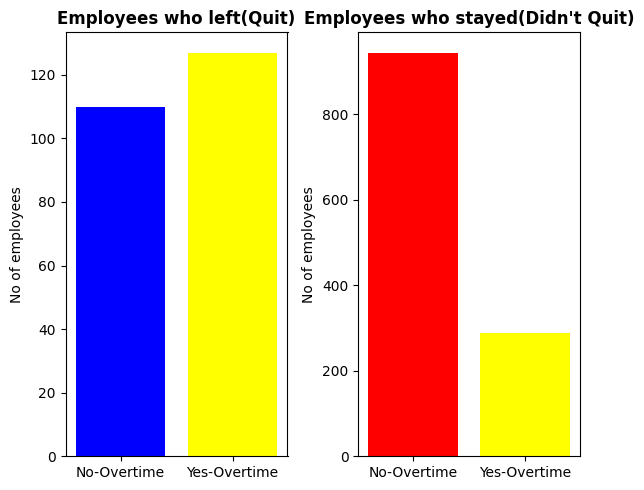

In [23]:
#q2-- How does overtime affect Employee Attrition?

overtime_attr = pd.crosstab(df['Attrition'], df['OverTime'])

fig, axes = plt.subplots(1, 2, figsize=[6,5])

labels = ['No-Overtime', 'Yes-Overtime']

axes[0].bar(labels, overtime_attr.loc['Yes'], color = ['Blue', 'Yellow'])
axes[0].set_title('Employees who left(Quit)', fontweight= 'bold')
axes[0].set_ylabel('No of employees')

axes[1].bar(labels, overtime_attr.loc['No'], color = ['Red', 'Yellow'])
axes[1].set_title("Employees who stayed(Didn't Quit)", fontweight = 'bold')
axes[1].set_ylabel('No of employees')

plt.tight_layout()
plt.show()

In [24]:
#Answer-- Among the employees who quit their job, the number of employees who worked overtime was more than those who didnt work overtime.
#      -- And among those who stayed, there were more who didnt work overtime.

#      -- Therefore, we can conclude that overtime is an important factor and can sometimes be a major reason behind why an employee leaves their company

In [25]:
#q3-- Are employees with less work experience more likely to quit?

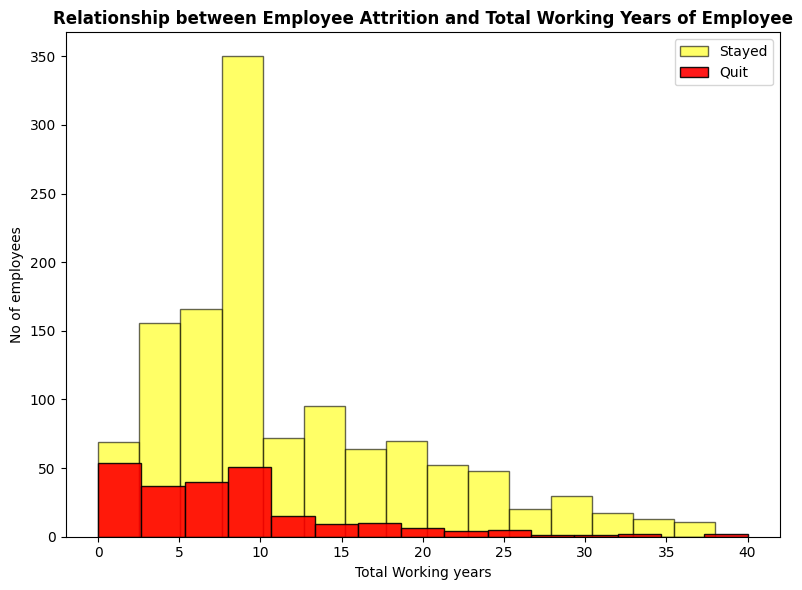

In [26]:
quit = df[df['Attrition'] == 'Yes']['TotalWorkingYears']
stayed = df[df['Attrition'] == 'No']['TotalWorkingYears']

plt.figure(figsize=(8,6))

plt.hist(stayed, bins = 15, label = 'Stayed', alpha = 0.6, color= 'yellow', edgecolor = 'black')
plt.hist(quit, bins = 15, label = 'Quit', alpha = 0.9, color = 'red', edgecolor = 'black')

plt.title('Relationship between Employee Attrition and Total Working Years of Employee', fontweight = 'bold')
plt.xlabel('Total Working years')
plt.ylabel('No of employees')

plt.legend()
plt.tight_layout()
plt.show()


In [27]:
#Answer--- Employee Attrition is highly related to the total working years.. The histogram shows that employees with less than 10
#      --- years of work experience are more likely to leave the company while senior veterans(around 30 years of work experience)
#      --- rarely leave the company.

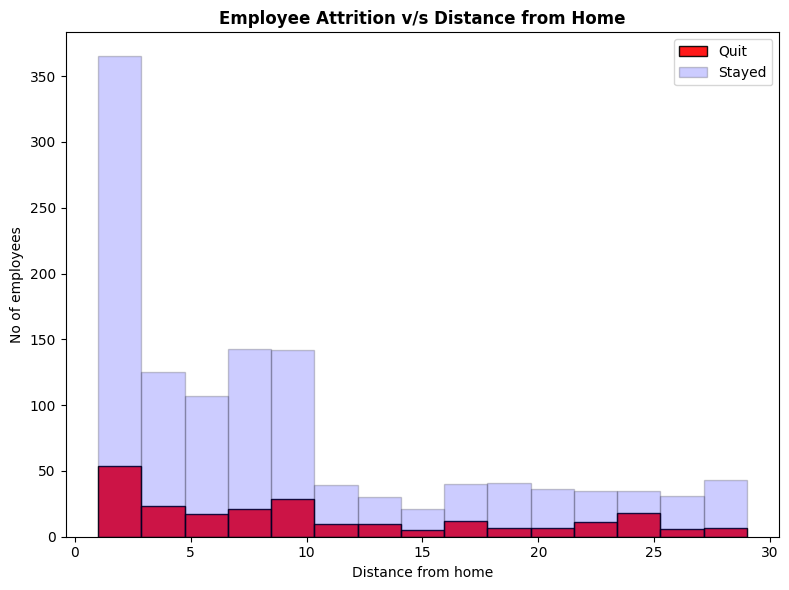

In [28]:
#q4-- Does distance from home affect employee attrition?

quit_dist = df[df['Attrition'] == 'Yes']['DistanceFromHome']
stayed_dist = df[df['Attrition'] == 'No']['DistanceFromHome']

plt.figure(figsize=(8,6))

plt.hist(quit_dist, label = 'Quit', bins = 15, alpha = 0.9, color = 'Red', edgecolor = 'Black')
plt.hist(stayed_dist, label = 'Stayed', bins = 15, alpha = 0.2, color = 'Blue', edgecolor = 'Black')

plt.title('Employee Attrition v/s Distance from Home', fontweight = 'bold')
plt.xlabel('Distance from home')
plt.ylabel('No of employees')

plt.legend()
plt.tight_layout()
plt.show()

In [29]:
#Answer-- Majority of employees who stayed have their homes near to their workplace

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
BusinessTravel
Travel_Rarely        156
Travel_Frequently     69
Non-Travel            12
Name: count, dtype: int64


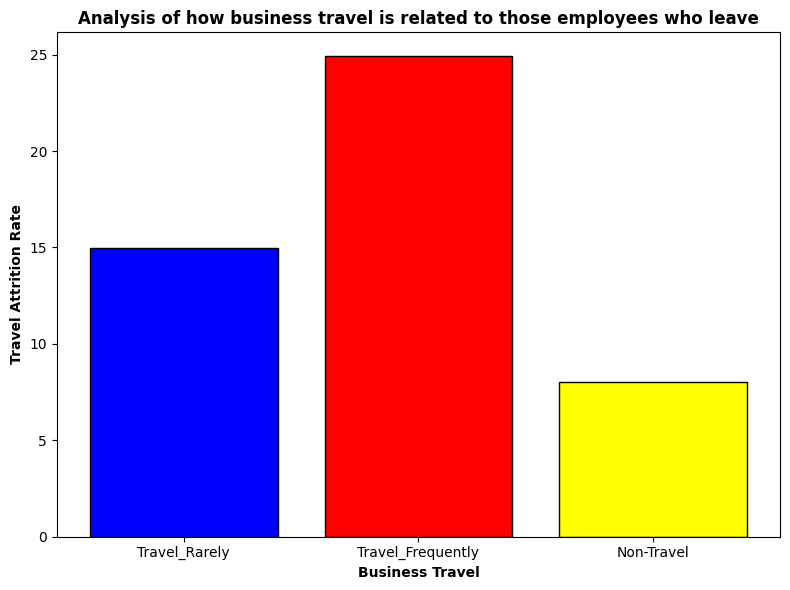

In [30]:
#q5-- Does more business travel lead to more employee attrition

travel_all = df['BusinessTravel'].value_counts()
print(travel_all)

#Travelling data among those employees who left the company

travel_left = df[df['Attrition'] == 'Yes']['BusinessTravel'].value_counts()
print(travel_left)

#Calculating the travel_attrition rate
travel_attrition_rate = (travel_left / travel_all)*100

plt.figure(figsize=(8,6))

plt.bar(travel_attrition_rate.index, travel_attrition_rate.values, color= ['Blue', 'Red', 'Yellow'], edgecolor= 'Black')

plt.title('Analysis of how business travel is related to those employees who leave', fontweight= 'bold')
plt.xlabel('Business Travel', fontweight= 'bold')
plt.ylabel('Travel Attrition Rate', fontweight= 'bold')

plt.tight_layout()
plt.show()

In [31]:
#Observation-- Among all employees who travelled rarely, around 15% left
#           -- Among all employees who travelled frequently, around 25% left

#Answer-- Employees who are required to travel frequently experience a higher overall higher attrition rate as compared to 
#      -- those who travel less.. This shows that More business travel can be a significant factor which drives someone towards
#      -- leaving the company.. 

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
Department
Research & Development    133
Sales                      92
Human Resources            12
Name: count, dtype: int64


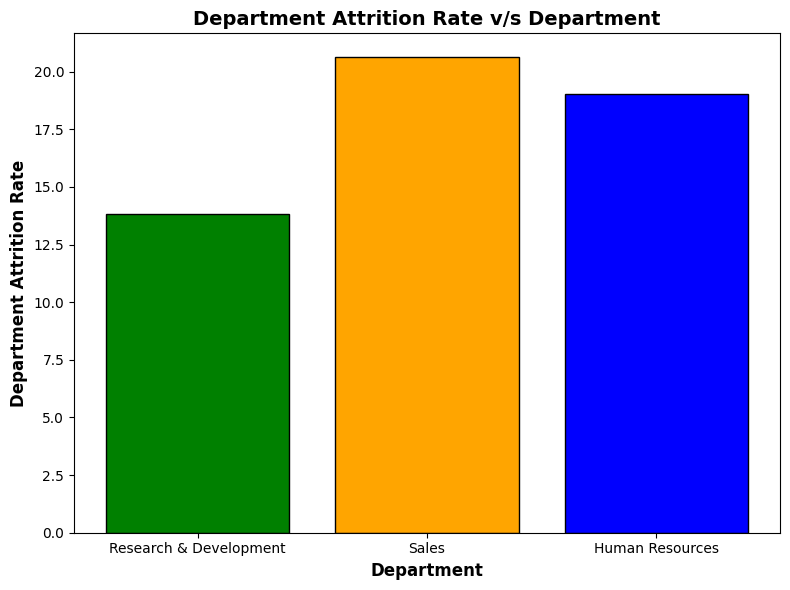

In [32]:
#q6-- Does the department in which the employee works affect his/hers decision of leaving the company?

dep = df['Department'].value_counts()
print(dep)

dep_left = df[df['Attrition'] == 'Yes']['Department'].value_counts()
print(dep_left)

dep_attrition_rate = (dep_left/dep)*100

plt.figure(figsize=(8,6))

plt.bar(dep_attrition_rate.index, dep_attrition_rate.values, color=['Green', 'Orange', 'Blue'], edgecolor='Black')

plt.title('Department Attrition Rate v/s Department', fontweight= 'bold', fontsize= 14)
plt.xlabel('Department', fontweight = 'bold', fontsize= 12)
plt.ylabel('Department Attrition Rate', fontweight= 'bold', fontsize= 12)

plt.tight_layout()
plt.show()

In [33]:
#Observation-- Among all employees who were in R&D, around 14% left
#           -- Among all employees who were in Sales, around 21% left
#           -- Among all employees who were in HR, around 18% left

#Answer-- Employees who were in Sales experienced a little high attrition rate compared to HR and significantly high as compared to R&D.
#      -- This shows that the employees in R&D have a less tendency of leaving the company as compared to Sales and HR



C:\Users\aryan\AppData\Local\Temp\ipykernel_14620\3465034114.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stayed_age, left_age], labels = ['Stayed', 'Left'], patch_artist=True, widths= 0.5)


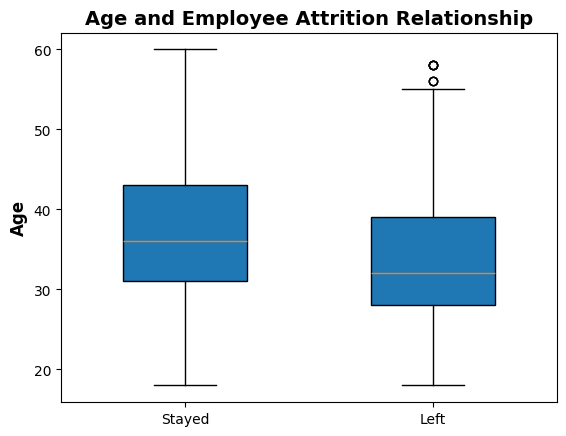

In [34]:
#q7-- At what age do employees tend to quit?

stayed_age = df[df['Attrition'] == 'No']['Age']
left_age = df[df['Attrition'] == 'Yes']['Age']

plt.boxplot([stayed_age, left_age], labels = ['Stayed', 'Left'], patch_artist=True, widths= 0.5)

plt.title('Age and Employee Attrition Relationship', fontweight= 'bold', fontsize= 14)
plt.ylabel('Age', fontweight= 'bold', fontsize= 12)

plt.show()

In [ ]:
#Observation--

# The median age of employees who left the company is noticeably lower than the median age of those who stayed. 
# The entire interquartile range (the middle 50% of the data) for the "Left" group is shifted downward on the age scale, 
# indicating a higher concentration of younger employees.

#Conclusion--

# Employee turnover is disproportionately driven by younger staff members,
# specifically those in their late twenties to early thirties whereas 
# older more established employees demonstrate a significantly higher likelihood of staying with the company.

#---- Younger employees have a higher tendency of leaving the company
#---- The circles at the top of the left part(in boxplot(q7)) are outliers.. 